In [80]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict, Literal
from pydantic import BaseModel, Field
from IPython.display import Image
from dotenv import load_dotenv

load_dotenv()

True

In [81]:
model = ChatGroq(model = 'llama-3.1-8b-instant')

In [82]:
class SentimentSchema(BaseModel) :
    sentiment : Literal['positive','negative'] = Field(description='sentiment of the provided review')

In [83]:
model_with_stuctured_output = model.with_structured_output(SentimentSchema)
model_with_stuctured_output.invoke('the product is not bad').sentiment

'positive'

In [84]:
class ReviewSchema(TypedDict):
    review : str
    sentiment : Literal['positive', 'negative']
    dignosis : dict
    response : str

In [85]:
def find_sentiment(state: ReviewSchema) :
    prompt = f'find the sentiment of the review {state["review"]}'
    sentiment = model_with_stuctured_output.invoke(prompt).sentiment
    return {'sentiment':sentiment}

In [86]:
# conditional function
def check_sentiment(state:ReviewSchema) -> Literal['positive_response', 'run_dignosis'] :
    if state['sentiment'] == 'positive':
        return 'positive_response'
    else :
        return 'run_dignosis'

In [87]:
def positive_response(state:ReviewSchema):
    prompt = f"""write a warm thank you message in response to this review\n 
    \"{state['review']}\" \n and also , kindly ask the user to leave feedback on our website.
    """
    response = model.invoke(prompt).content
    return {
        'response':response
    }    

In [88]:
class DignosisSchema(BaseModel):
    issue_type : Literal['UX', 'Performance', 'Bug','Support', 'Other'] = Field(description="The category of issue mentioned in the review")
    tone : Literal['angry','frusteted','calm','disppointed'] = Field(description='the emotional tone expressed by the user')
    urgency : Literal['low','high','medium'] = Field(description='How urgent or critical the issue appears to be')
    
dignosis_model = model.with_structured_output(DignosisSchema)

def run_dignosis(state:ReviewSchema):
    prompt = f"""Diagnose this negative review:\n {state['review']}\n 
    Return : issue_type, tone, and urgency."""
    response = dignosis_model.invoke(prompt)
    return {'dignosis': response.model_dump()}

In [89]:
prompt = f"""Diagnose this negative review:\n {negative_review}\n 
Return : issue_type, tone, and urgency."""
response = dignosis_model.invoke(prompt)


In [90]:
response

DignosisSchema(issue_type='Bug', tone='angry', urgency='high')

In [91]:
def negative_response(state:ReviewSchema):
    prompt = f"""
    You are a support assistant. The user had a \"{state['dignosis']['issue_type']}\" issue,
    sounded \"{state['dignosis']['tone']}\"
    and marked urgency as \"{state['dignosis']['urgency']}\"\n
    Write an empathetic, helpful resolution message. """
    
    response = model.invoke(prompt).content
    return {'response' : response}

In [92]:
graph = StateGraph(ReviewSchema)

graph.add_node('find_sentiment', find_sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('run_dignosis', run_dignosis)
graph.add_node('negative_response', negative_response)


# edges 
graph.add_edge(START, 'find_sentiment')
graph.add_conditional_edges('find_sentiment', check_sentiment)
graph.add_edge('run_dignosis', 'negative_response')
graph.add_edge('negative_response', END)
graph.add_edge('positive_response', END)

In [93]:
workflow = graph.compile()

In [94]:
positive_review = """I've been using this app for about a month now, and I must say, the user interface is incredibly clean and intuitive.
Everything is exactly where you'd expect it to be. It's rare to find something that just works without needing a tutorial.
Great job to the design team!"""

negative_review = """ I've been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried
reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."""

In [95]:
# initial_state = {"review" :"the product is good"}
initial_state = {"review" :negative_review}

final_state = workflow.invoke(initial_state)
final_state

{'review': " I've been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried\nreinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.",
 'sentiment': 'negative',
 'dignosis': {'issue_type': 'Bug', 'tone': 'angry', 'urgency': 'high'},
 'response': "Dear [User],\n\nI'm so sorry to hear that you're experiencing a frustrating issue with our system. I can sense the urgency and frustration in your initial message, and I want to assure you that I'm here to help resolve it as quickly as possible.\n\nI've taken a closer look at the problem you've described, and I'm working on a solution for you right away. Please know that I'm committed to finding a resolution that works for you and minimizes any disruption to your work.\n\nIn the meantime, I want to offer you some additional support and resources to help alleviate any inconvenience this issue may have caused. If you'd like, I can prov

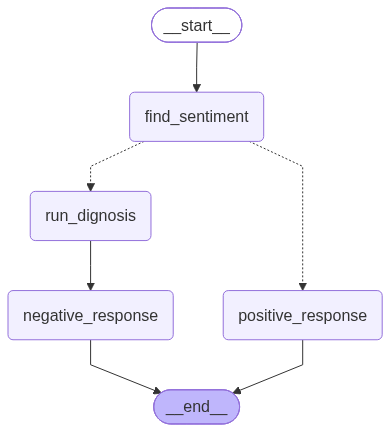

In [96]:
Image(workflow.get_graph().draw_mermaid_png())

In [97]:
# find sentiment -> if -ve --> dignose --> print response
#  if +ve --> response
